In [1]:
import numpy as np
import pandas as pd
from scipy import sparse
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import joblib
import os

# Paths
X_path = "E:/LogAnomalyDetector/data/X_features.npz"
y_path = "E:/LogAnomalyDetector/data/y_labels.csv"
model_path = "E:/LogAnomalyDetector/models/best_model.joblib"

# Load features
X = sparse.load_npz(X_path)

# Load labels
y_df = pd.read_csv(y_path)
y = y_df["true_label"].astype(int)

print("Loaded feature matrix shape:", X.shape)
print("Loaded labels shape:", y.shape)
print("\nLabel distribution:")
print(y.value_counts())


Loaded feature matrix shape: (5, 28)
Loaded labels shape: (5,)

Label distribution:
true_label
0    3
1    2
Name: count, dtype: int64


In [2]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape, y_train.shape)
print("Test shape:", X_test.shape, y_test.shape)

print("\nTrain label distribution:")
print(pd.Series(y_train).value_counts())

print("\nTest label distribution:")
print(pd.Series(y_test).value_counts())


Train shape: (3, 28) (3,)
Test shape: (2, 28) (2,)

Train label distribution:
true_label
0    2
1    1
Name: count, dtype: int64

Test label distribution:
true_label
0    1
1    1
Name: count, dtype: int64


In [3]:
# Train Random Forest model
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

rf.fit(X_train, y_train)

print("Model training completed.")


Model training completed.


In [4]:
# Predict on test set
y_pred = rf.predict(X_test)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Confusion Matrix:
[[1 0]
 [1 0]]

Classification Report:
              precision    recall  f1-score   support

           0       0.50      1.00      0.67         1
           1       0.00      0.00      0.00         1

    accuracy                           0.50         2
   macro avg       0.25      0.50      0.33         2
weighted avg       0.25      0.50      0.33         2



C:\Users\dayus\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\dayus\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\dayus\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

In [5]:
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))


Confusion Matrix:
[[1 0]
 [1 0]]

Classification Report:
              precision    recall  f1-score   support

           0       0.50      1.00      0.67         1
           1       0.00      0.00      0.00         1

    accuracy                           0.50         2
   macro avg       0.25      0.50      0.33         2
weighted avg       0.25      0.50      0.33         2



In [6]:
# Save trained model
joblib.dump(rf, model_path)

print("Model saved to:", model_path)


Model saved to: E:/LogAnomalyDetector/models/best_model.joblib


In [1]:
import pandas as pd

# Load your labeled dataset
df = pd.read_csv(r"E:\LogAnomalyDetector\data\labeled_logs.csv")

print("Total rows in labeled_logs.csv:", len(df))
print("\nLabel distribution:")
print(df["true_label"].value_counts())


Total rows in labeled_logs.csv: 5

Label distribution:
true_label
0    3
1    2
Name: count, dtype: int64


In [2]:
import pandas as pd

# Load the large parsed dataset
df = pd.read_csv(r"E:\LogAnomalyDetector\data\adfa_parsed.csv")

print("Total rows in adfa_parsed.csv:", len(df))
print("Columns:", df.columns.tolist())

# IMPORTANT: Check what column represents log level or label
# If you have a 'label' column already, tell me.
# Otherwise, we will create labels using rules.

print("\nFirst 5 rows:")
print(df.head())


Total rows in adfa_parsed.csv: 5990
Columns: ['filepath', 'split', 'is_anomaly', 'timestamp', 'host', 'message']

First 5 rows:
                                            filepath   split  is_anomaly  \
0  ADFA-LD\Attack_Data_Master\Adduser_1\UAD-Addus...  ATTACK           1   
1  ADFA-LD\Attack_Data_Master\Adduser_1\UAD-Addus...  ATTACK           1   
2  ADFA-LD\Attack_Data_Master\Adduser_1\UAD-Addus...  ATTACK           1   
3  ADFA-LD\Attack_Data_Master\Adduser_1\UAD-Addus...  ATTACK           1   
4  ADFA-LD\Attack_Data_Master\Adduser_1\UAD-Addus...  ATTACK           1   

              timestamp  host  \
0  2024-03-16T11:40:08Z  ADFA   
1  2024-03-16T11:40:08Z  ADFA   
2  2024-03-16T11:40:08Z  ADFA   
3  2024-03-16T11:40:08Z  ADFA   
4  2024-03-16T11:40:08Z  ADFA   

                                             message  
0  265 168 168 265 168 168 168 265 168 265 168 16...  
1  3 104 91 265 142 142 104 3 175 3 142 142 146 1...  
2  265 43 3 265 43 168 265 168 168 168 3 43 168 3..

In [3]:
# Create clean labeled training dataset from ADFA

# Keep only necessary columns
df_train = df[["message", "is_anomaly"]].copy()

# Rename label column to match your pipeline
df_train = df_train.rename(columns={"is_anomaly": "true_label"})

print("Final training dataset shape:", df_train.shape)
print("\nLabel distribution:")
print(df_train["true_label"].value_counts())

# Save to disk
out_path = r"E:\LogAnomalyDetector\data\labeled_logs_large.csv"
df_train.to_csv(out_path, index=False)

print("\nSaved large labeled dataset to:")
print(out_path)


Final training dataset shape: (5990, 2)

Label distribution:
true_label
0    5226
1     764
Name: count, dtype: int64

Saved large labeled dataset to:
E:\LogAnomalyDetector\data\labeled_logs_large.csv


In [4]:
import pandas as pd

# Load the large labeled dataset
df = pd.read_csv(r"E:\LogAnomalyDetector\data\labeled_logs_large.csv")

print("Dataset shape:", df.shape)
print("\nLabel distribution:")
print(df["true_label"].value_counts())


Dataset shape: (5990, 2)

Label distribution:
true_label
0    5226
1     764
Name: count, dtype: int64


In [5]:
from sklearn.model_selection import train_test_split

X_text = df["message"].astype(str)
y = df["true_label"].astype(int)

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text,
    y,
    test_size=0.3,
    stratify=y,
    random_state=42
)

print("Train size:", len(X_train_text))
print("Test size:", len(X_test_text))
print("\nTrain label distribution:")
print(y_train.value_counts())
print("\nTest label distribution:")
print(y_test.value_counts())


Train size: 4193
Test size: 1797

Train label distribution:
true_label
0    3658
1     535
Name: count, dtype: int64

Test label distribution:
true_label
0    1568
1     229
Name: count, dtype: int64


In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=300,
    min_df=2
)

X_train = vectorizer.fit_transform(X_train_text)
X_test = vectorizer.transform(X_test_text)

print("Train feature shape:", X_train.shape)
print("Test feature shape:", X_test.shape)


Train feature shape: (4193, 300)
Test feature shape: (1797, 300)


In [7]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

rf.fit(X_train, y_train)

print("Model training completed.")


Model training completed.


In [8]:
from sklearn.metrics import classification_report, confusion_matrix

y_test_pred = rf.predict(X_test)

print("Confusion Matrix on ADFA Test Set:")
print(confusion_matrix(y_test, y_test_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred, digits=4))


Confusion Matrix on ADFA Test Set:
[[1546   22]
 [  39  190]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9754    0.9860    0.9807      1568
           1     0.8962    0.8297    0.8617       229

    accuracy                         0.9661      1797
   macro avg     0.9358    0.9078    0.9212      1797
weighted avg     0.9653    0.9661    0.9655      1797



In [9]:
from joblib import dump

model_path = r"E:\LogAnomalyDetector\models\best_model.joblib"
vec_path = r"E:\LogAnomalyDetector\models\tfidf_vectorizer.joblib"

dump(rf, model_path)
dump(vectorizer, vec_path)

print("Saved new model to:", model_path)
print("Saved new vectorizer to:", vec_path)


Saved new model to: E:\LogAnomalyDetector\models\best_model.joblib
Saved new vectorizer to: E:\LogAnomalyDetector\models\tfidf_vectorizer.joblib


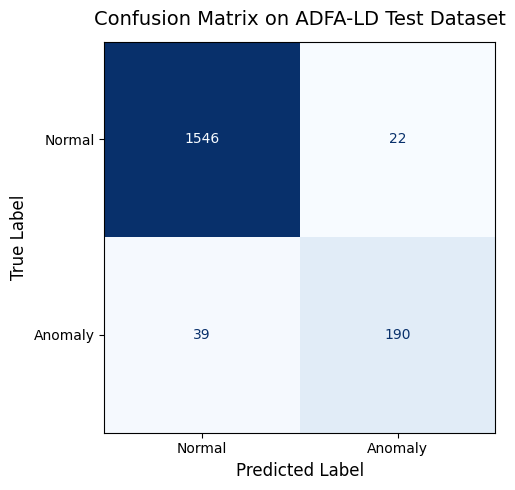

Saved ADFA confusion matrix to:
E:\LogAnomalyDetector\reports\confusion_matrix_adfa.png


In [10]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

plt.figure(figsize=(6, 5))

disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, y_test_pred),
    display_labels=["Normal", "Anomaly"]
)

disp.plot(values_format="d", cmap="Blues", ax=plt.gca(), colorbar=False)

plt.title("Confusion Matrix on ADFA-LD Test Dataset", fontsize=14, pad=12)
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.tight_layout()

# Save for report
plt.savefig(r"E:\LogAnomalyDetector\reports\confusion_matrix_adfa.png", dpi=300)

plt.show()

print("Saved ADFA confusion matrix to:")
print(r"E:\LogAnomalyDetector\reports\confusion_matrix_adfa.png")
